In [30]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('sci.mplstyle')

In [31]:
def RK4(a, b, N, dieukiendau, phuongtrinh):
    h = (b - a) / N                  # tinh kich thuoc buoc thoi gian
    x = np.linspace(a, b, N + 1)     # tao mang thoi gian tu a den b gom N+1 diem
    y = np.zeros((N + 1, len(dieukiendau)))# tao mang nghiem cho he ODE
    y[0] = dieukiendau                     # gan dieu kien dau

    for i in range(N):               # lap qua tung buoc thoi gian
        k1 = phuongtrinh(x[i], y[i]) # dao ham tai dau buoc
        k2 = phuongtrinh(x[i] + h/2, y[i] + h*k1/2) # dao ham tai diem giua dung k1
        k3 = phuongtrinh(x[i] + h/2, y[i] + h*k2/2) # dao ham tai diem giua dung k2
        k4 = phuongtrinh(x[i] + h, y[i] + h*k3)     # dao ham tai cuoi buoc

        y[i+1] = y[i] + h*(k1 + 2*k2 + 2*k3 + k4)/6 # cap nhat nghiem RK4

    return x, y                      # tra ve mang thoi gian va nghiem

In [32]:
def thu_san_moi(t, Y):
    global alpha, beta, delta, gamma

    x = Y[0]   # x
    y = Y[1]   # y

    dx_dt = alpha * x - beta * x * y
    dy_dt = delta * x * y - gamma * y

    # F[0] = theta0
    # F[1] = omega0 
    F = np.array([dx_dt, dy_dt])
    return F

In [33]:
alpha = 1
beta = 0.5
gamma = 0.75
delta  = 0.25 

t_min = 0
t_max = 50
N_t = 1000

x_0 = 2
y_0 = 1

Y_0_thu_san_moi = np.array([x_0,y_0])

In [36]:
t_thu_san_moi, Y_thu_san_moi = RK4(t_min,t_max,N_t,Y_0_thu_san_moi, thu_san_moi)


In [38]:
def ghifile(t_thu_san_moi, Y_thu_san_moi, filename="thu_san_moi-RK4"):
    filename = f"KQ_{filename}.txt"

    with open(filename, "w", encoding="utf-8") as file:
        file.write("# Giai bai toan dong dien RK4\n")
        file.write("#\n")
        file.write(f"# {'t':>20s} {'x':>20s} {'y':>20s}\n")

        for t_step in range(len(t_thu_san_moi)):
            file.write(f"  {t_thu_san_moi[t_step]:20.8e} {Y_thu_san_moi[t_step, 0]:20.8e} {Y_thu_san_moi[t_step, 1]:20.8e}\n")

ghifile(t_thu_san_moi, Y_thu_san_moi, filename="thu_san_moi-RK4")

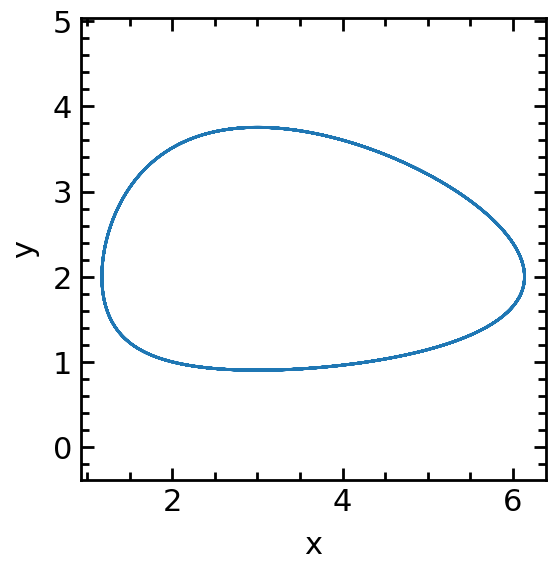

In [40]:
t_thu_san_moi, x_thu_san_moi, y_thu_san_moi= np.loadtxt("KQ_thu_san_moi-RK4.txt", comments="#", unpack=True)

plt.figure(figsize=(6,6))
plt.plot(x_thu_san_moi, y_thu_san_moi, lw=2)
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.savefig("quydao_thusanmoi.png", dpi=300)
plt.show()

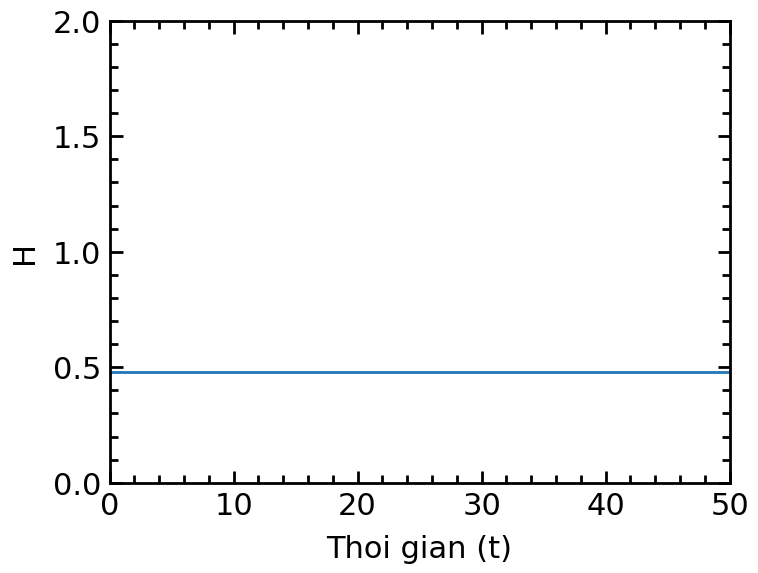

In [50]:
H_thusanmoi = delta * x_thu_san_moi - gamma * np.log(x_thu_san_moi) + beta * y_thu_san_moi - alpha * np.log(y_thu_san_moi)
plt.figure(figsize=(8,6))
plt.plot(t_thu_san_moi, H_thusanmoi, lw=2)


plt.xlabel("Thoi gian (t)")
plt.ylabel("H")

plt.ylim(0,2)
plt.xlim(0,t_max)

plt.savefig("baotoan_thusanmoi.png", dpi=300)
plt.show()